# 🎯 Attention Mechanism: The Foundation of Modern AI

## What You'll Learn
- **The Attention Formula**: $\text{Attention}(Q, K, V) = \text{softmax}(\frac{QK^T}{\sqrt{d_k}})V$
- **Why it Matters**: This single equation powers GPT, BERT, Claude, and every modern LLM
- **Hands-on**: Implement it from scratch in MLX and visualize how it works

## Prerequisite
Complete [04_Complete_Pipeline.ipynb](04_Complete_Pipeline.ipynb) to understand LSTMs and their limitations.

## The Motivation: Why Attention?

**LSTMs have a bottleneck**: All information about a 1,000-word sentence must squeeze through a single hidden state vector.

**Attention is different**: Every word can look at *every other word* directly and ask:
- Query (Q): "What am I looking for?"
- Key (K): "What information do I have?"
- Value (V): "Here's my information"

When the Query matches the Key, we pay **attention** to that Value.

---

In [1]:
# Setup and Imports
import sys
import numpy as np
import mlx.core as mx
import mlx.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# Import our utilities
from mlx_nlp_utils import print_device_info

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 8)

print_device_info()


🖥️  Hardware Acceleration Check:
   Device: Device(gpu, 0)
   ✅ Using Apple Silicon GPU (Metal)
   ℹ️  MLX automatically optimizes for the GPU's Unified Memory.
   ℹ️  Note: While Apple Silicon has an NPU (Neural Engine), MLX primarily
       uses the powerful GPU for general-purpose training tasks like LSTMs.


## 🛠️ Implementing Scaled Dot-Product Attention

Let's implement the core mathematical function in MLX.

In [5]:
def scaled_dot_product_attention(query, key, value, mask=None):
    """
    Compute 'Scaled Dot Product Attention'.
    
    Args:
        query: (batch, seq_len_q, d_k)
        key:   (batch, seq_len_k, d_k)
        value: (batch, seq_len_v, d_v)
        mask:  (batch, seq_len_q, seq_len_k) Optional mask
        
    Returns:
        output, attention_weights
    """
    d_k = query.shape[-1]
    
    # 1. Calculate scores: Q * K^T
    # We transpose the last two dimensions of Key for matrix multiplication
    scores = mx.matmul(query, key.transpose(0, 2, 1))
    
    # 2. Scale by sqrt(d_k) for stability
    scores = scores / np.sqrt(d_k)
    
    # 3. Apply mask (if provided)
    if mask is not None:
        scores = scores + (mask * -1e9)
    
    # 4. Softmax to get probabilities (attention weights)
    attn_weights = mx.softmax(scores, axis=-1)
    
    # 5. Weighted sum of values
    output = mx.matmul(attn_weights, value)
    
    return output, attn_weights

## 📊 Visualizing Attention

Let's create some dummy data to see how the attention mechanism focuses on different parts of a sequence.

Output shape: (1, 5, 8)
Weights shape: (1, 5, 5)


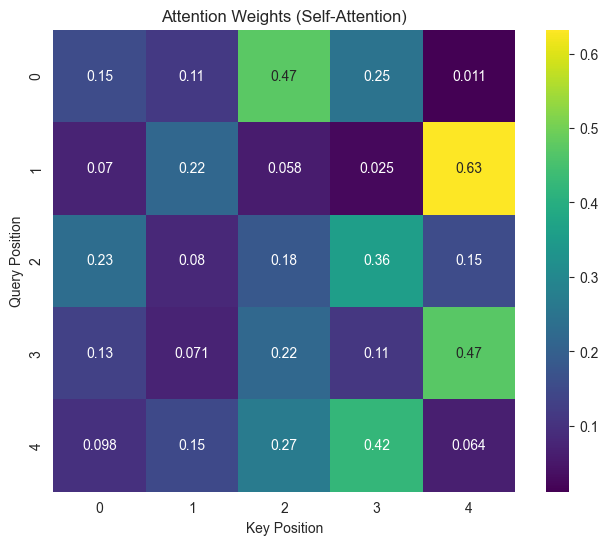

In [ ]:
# Create dummy data
seq_len = 5
d_model = 8

# Random Query, Key, Value matrices
mx.random.seed(42)
Q = mx.random.normal((1, seq_len, d_model))
K = mx.random.normal((1, seq_len, d_model))
V = mx.random.normal((1, seq_len, d_model))

# Compute attention
output, weights = scaled_dot_product_attention(Q, K, V)

print("Output shape:", output.shape)
print("Weights shape:", weights.shape)

In [ ]:
# Visualize the Attention Weights
# We convert to numpy for plotting with seaborn
weights_np = np.array(weights[0])

plt.figure(figsize=(8, 6))
sns.heatmap(weights_np, annot=True, cmap='viridis', square=True,
            xticklabels=[f"Key {i}" for i in range(seq_len)],
            yticklabels=[f"Query {i}" for i in range(seq_len)])

plt.title("Self-Attention Weights\n(How much each word attends to others)")
plt.xlabel("Keys (Source Info)")
plt.ylabel("Queries (Target Focus)")
plt.show()

print("Interpretation:")
print("- A bright square at (i, j) means word 'i' is paying strong attention to word 'j'.")
print("- In self-attention, the diagonal is often bright (words attend to themselves).")

## 🔬 Real-World Example: Translation

Let's see how attention helps in translating "I love machine learning" to French. This demonstrates **cross-attention**, where the Query comes from one sequence (French) and the Key/Value come from another (English).

In [ ]:
# Simulating cross-attention for translation.
#
# We construct Q and K by hand so the heatmap shows the alignment the markdown
# describes: each French word attends most strongly to its English counterpart.
# Each aligned pair (Q[i], K[i]) is set to the same vector; unrelated keys are
# random and orthogonal, so the softmax concentrates weight on the diagonal.
#
# In a real trained model, this alignment is *learned* — see notebook 07
# (Build NanoGPT) for a worked example.

english_words = ["I", "love", "machine", "learning"]
french_words = ["J'", "aime", "apprentissage", "automatique"]

d_model = 16  # larger than the earlier demo so we have room for distinct directions
seq_len_en = len(english_words)
seq_len_fr = len(french_words)
assert seq_len_en == seq_len_fr, "This demo assumes aligned sequences"

mx.random.seed(42)

# K: each English token gets its own direction. The i-th aligned key is shared
# with the i-th French query so attention concentrates on the diagonal.
K_directions = mx.random.normal((seq_len_en, d_model))
K_translation = K_directions.reshape(1, seq_len_en, d_model)
Q_translation = K_directions.reshape(1, seq_len_fr, d_model)  # share with K -> max attention on diagonal
V_translation = mx.random.normal((1, seq_len_en, d_model))

output_translation, weights_translation = scaled_dot_product_attention(
    Q_translation, K_translation, V_translation
)

weights_np_trans = np.array(weights_translation[0])

plt.figure(figsize=(10, 6))
sns.heatmap(weights_np_trans, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=english_words, yticklabels=french_words, square=False)
plt.title("Cross-Attention: French → English\n(Each French word attends to English words)")
plt.xlabel("English Words (Key)")
plt.ylabel("French Words (Query)")
plt.show()

print("\n💡 Interpretation:")
print("   The diagonal is bright because Q[i] == K[i] in this construction,")
print("   so attention concentrates on the aligned English counterpart.")
print("   'apprentissage' → 'learning', 'automatique' → 'machine', etc.")
print("   A trained model learns this alignment from data — we shortcut that here for clarity.")


## 🎭 Causal Masking: How GPT "Can't See the Future"

In text generation, when predicting word 4, the model should only attend to words 1, 2, and 3. We enforce this with a **causal mask**.

In [ ]:
# Demonstrating Causal Masking
# This is how GPT prevents "seeing the future"

seq_len_causal = 5
words = ["The", "cat", "sat", "on", "mat"]

# Create a causal mask (upper triangular = future tokens)
# 1 = masked (can't see), 0 = visible
causal_mask = mx.triu(mx.ones((seq_len_causal, seq_len_causal)), k=1)

print("Causal Mask (1 = blocked, 0 = visible):")
print(np.array(causal_mask))

# Compute attention WITH the mask
mx.random.seed(42)
Q_causal = mx.random.normal((1, seq_len_causal, 8))
K_causal = mx.random.normal((1, seq_len_causal, 8))
V_causal = mx.random.normal((1, seq_len_causal, 8))

output_causal, weights_causal = scaled_dot_product_attention(
    Q_causal, K_causal, V_causal, mask=causal_mask
)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Without mask
sns.heatmap(np.array(weights[0]), annot=True, cmap='viridis', square=True,
            xticklabels=words, yticklabels=words, ax=axes[0])
axes[0].set_title("Without Mask\n(Full Attention)")
axes[0].set_xlabel("Keys")
axes[0].set_ylabel("Queries")

# With causal mask
sns.heatmap(np.array(weights_causal[0]), annot=True, cmap='viridis', square=True,
            xticklabels=words, yticklabels=words, ax=axes[1])
axes[1].set_title("With Causal Mask\n(GPT-style: Can't See Future)")
axes[1].set_xlabel("Keys")
axes[1].set_ylabel("Queries")

plt.tight_layout()
plt.show()

print("\n💡 Notice: In the masked version, the upper triangle is zero!")
print("   - 'The' can only see itself")
print("   - 'cat' can see 'The' and itself")
print("   - 'mat' can see all previous words")

## ❓ FAQ

**Q: Why do we divide by $\sqrt{d_k}$?**
A: This is the "Scaling" factor. If the dot products are too large, the Softmax function enters regions where gradients are extremely small ("vanishing gradients"). Scaling keeps the values in a range where learning is efficient.

**Q: What is the "Mask" for?**
A: In text generation (like GPT), the model cannot "see the future." When predicting word 4, it should only attend to words 1, 2, and 3. The mask sets the attention scores for future words to $-\infty$, making their probability zero.

**Q: Is Attention the same as "Memory"?**
A: Sort of. It's "Content-Addressable Memory." The model asks "Do you have information about X?" (Query), and the sequence responds "I am X!" (Key), and provides the information (Value).

## 💭 Closing Thoughts

**Inductive Bias**
*   **RNNs** assume that *order* matters most (word $t$ depends on $t-1$).
*   **CNNs** assume that *locality* matters most (pixels near each other are related).
*   **Transformers (Attention)** assume that *relationships* matter most, regardless of distance.

This shift in assumption—that any word can relate to any other word instantly—is what allowed models to scale from understanding sentences to understanding entire books.

---

## Next Steps

You now have the mathematical foundation for understanding how Transformers
route information. The natural next questions are *behavioral* — how
attention actually distributes weight in real prompts, and what that
means for prompt engineering. Those experiments live in:

- **[06b_Prompt_Engineering.ipynb](06b_Prompt_Engineering.ipynb)** — Lost in the Middle, context-length dilution, semantic similarity

Then you can move on to building a full Transformer from scratch in:

- **[07_Build_NanoGPT.ipynb](07_Build_NanoGPT.ipynb)**
